# Exercise 2 — Non-linearity in higher dimensions

**Insper · Artificial Neural Networks and Deep Learning · Activity 1**
Author: Eduardo Takei Yaginuma

Simple networks (a Perceptron) can only learn linear boundaries. Deep networks earn their
keep when the data is not linearly separable. This notebook contrasts two datasets of the
**same dimensionality** ($\mathbb{R}^5$) and the **same size** (500 samples per class) but
completely different structure — shifted Gaussians versus concentric spherical shells —
and shows that a measure computed *in 5D* (the radius) separates what a linear 2D
projection cannot.

> **Reproducibility.** `np.random.default_rng(42)`. The report threads one single generator
> through Exercises 1 and 2 in that order (see [`code/run_report.py`](../docs/exercises/data/code/run_report.py)),
> so the cell below replays Exercise 1's draws to leave the generator in the same state and
> reproduce the published numbers exactly. Libraries: `numpy`, `pandas`, `matplotlib`,
> `scikit-learn` (**PCA only** — no model is trained). Same code as
> [`code/ex2_nonlinearity.py`](../docs/exercises/data/code/ex2_nonlinearity.py).

In [1]:
"""Report style, inlined so the notebook runs standalone (mirrors src/style.py)."""
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

%matplotlib inline

# ---- neutrals ----------------------------------------------------------------
INK      = "#1a1a1a"   # primary text
INK_SOFT = "#4a4a4a"   # secondary text
HAIRLINE = "#c8c8c8"   # grid lines, spines
SURFACE  = "#ffffff"   # figure background
ACCENT   = "#1a1a1a"   # annotation strokes, always dashed so they never read as data

# Categorical palette (fixed order) + redundant marker shapes, so class identity
# never depends on colour alone. Worst of the six pairs is dE00 = 20.6 across
# normal vision and the three dichromacies; every hue clears WCAG non-text
# contrast on white.
SERIES  = ["#2166AC", "#8C510A", "#555555", "#CC79A7"]
MARKERS = ["o", "s", "^", "D"]

# ---- fonts: only what matplotlib ships, so nothing has to be installed -------
SERIF = "DejaVu Serif"
SANS  = "DejaVu Sans"
MONO  = "DejaVu Sans Mono"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "savefig.bbox": "tight",
    "font.family": SERIF, "font.size": 9, "axes.titlesize": 11, "axes.labelsize": 9.5,
    "legend.fontsize": 8.5, "xtick.labelsize": 8, "ytick.labelsize": 8,
    "text.color": INK, "axes.labelcolor": INK_SOFT, "axes.titlecolor": INK,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "axes.edgecolor": HAIRLINE, "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": HAIRLINE, "grid.linewidth": 0.5,
    "grid.alpha": 0.45, "axes.axisbelow": True,
    "legend.frameon": True, "legend.facecolor": SURFACE, "legend.edgecolor": HAIRLINE,
    "lines.linewidth": 2.0, "lines.markersize": 5,
})


def title(ax, text, sub=None):
    """Serif title, placed with ax.text so title and deck never collide."""
    ax.text(0.0, 1.085 if sub else 1.02, text, transform=ax.transAxes,
            fontfamily=SERIF, fontsize=12, color=INK, va="bottom", ha="left")
    if sub:
        ax.text(0.0, 1.018, sub, transform=ax.transAxes, fontsize=8,
                color=INK_SOFT, va="bottom", ha="left")


def legend_row(ax, ncols=4, y=-0.16):
    """Legend as a single row under the plot, so it never covers the data."""
    return ax.legend(loc="upper center", bbox_to_anchor=(0.5, y), ncols=ncols,
                     frameon=False, handletextpad=0.4, columnspacing=1.4)


def halo(txt, lw=2.2):
    """Surface-coloured outline behind a label sitting on top of the data."""
    txt.set_path_effects([pe.withStroke(linewidth=lw, foreground=SURFACE)])
    return txt


def mono_ticks(ax):
    """Tick labels are numbers, so they wear the mono face."""
    for lbl in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
        lbl.set_fontfamily(MONO)


print(f"fonts: {SERIF} / {SANS} / {MONO}")

fonts: DejaVu Serif / DejaVu Sans / DejaVu Sans Mono


In [2]:
from sklearn.decomposition import PCA

rng = np.random.default_rng(42)          # the one and only seed

# The report uses ONE generator for Exercises 1 and 2, in that order. Replaying
# Exercise 1's draws here leaves `rng` in exactly the state Exercise 2 sees in
# src/run_report.py, so every number below matches the published report.
# Set REPLAY_EX1 = False to run this notebook standalone: the conclusions are
# identical, but the sampling-noise figures (notably the Dataset II centre
# distance, which is pure noise around 0) will land on different values.
REPLAY_EX1 = True
if REPLAY_EX1:
    _MEANS = np.array([[2.0, 3.0], [5.0, 6.0], [8.0, 1.0], [15.0, 4.0]])
    _STDS = np.array([[0.8, 2.5], [1.2, 1.9], [0.9, 0.9], [0.5, 2.0]])
    for _s in (0.5, 1.0, 2.0, 4.0):                     # Exercise 1, item B
        for _k in range(4):
            rng.normal(loc=_MEANS[_k], scale=_STDS[_k] * _s, size=(100, 2))
    print("generator advanced past Exercise 1's 16 draws")

generator advanced past Exercise 1's 16 draws


---
## A — Dataset I: shifted Gaussians

500 samples per class from two 5D multivariate normals. The two classes differ in
**location and in shape**: $\Sigma_B$ has larger variances ($1.5$ against $1.0$ on the
diagonal) and a **negative** correlation between the first two features ($-0.7$), while
$\Sigma_A$ has a **positive** one ($+0.8$). So class B is both more spread out and tilted
the other way — the pair is not a simple translation.

In [3]:
N_PER_CLASS = 500

# ---- Dataset I: shifted Gaussians -------------------------------------------
MU_A = np.zeros(5)
MU_B = np.full(5, 1.5)

SIGMA_A = np.array([[1.0, 0.8, 0.1, 0.0, 0.0],
                    [0.8, 1.0, 0.3, 0.0, 0.0],
                    [0.1, 0.3, 1.0, 0.5, 0.0],
                    [0.0, 0.0, 0.5, 1.0, 0.2],
                    [0.0, 0.0, 0.0, 0.2, 1.0]])

SIGMA_B = np.array([[1.5, -0.7, 0.2, 0.0, 0.0],
                    [-0.7, 1.5, 0.4, 0.0, 0.0],
                    [0.2, 0.4, 1.5, 0.6, 0.0],
                    [0.0, 0.0, 0.6, 1.5, 0.3],
                    [0.0, 0.0, 0.0, 0.3, 1.5]])

# ---- Dataset II: concentric shells ------------------------------------------
# The statement gives rho ~ N(2.0, 0.4) and N(5.0, 0.4); 0.4 is read as the
# standard deviation (numpy's `scale`), the same convention used in Exercise 1.
R_CORE = (2.0, 0.4)     # class C: radius ~ N(2.0, 0.4)
R_SHELL = (5.0, 0.4)    # class D: radius ~ N(5.0, 0.4)
R_THRESHOLD = 3.35      # threshold inside the empty gap between the two shells

In [4]:
def dataset_gaussians(rng):
    """Dataset I - 500 samples per class from two 5D multivariate normals."""
    A = rng.multivariate_normal(MU_A, SIGMA_A, size=N_PER_CLASS)
    B = rng.multivariate_normal(MU_B, SIGMA_B, size=N_PER_CLASS)
    X = np.vstack([A, B])
    y = np.repeat([0, 1], N_PER_CLASS)          # 0 = Class A, 1 = Class B
    return X, y


X1, y1 = dataset_gaussians(rng)
print(f"Dataset I: X {X1.shape}, y {y1.shape}, samples per class {np.bincount(y1)}")

Dataset I: X (1000, 5), y (1000,), samples per class [500 500]


/var/folders/rt/cjr17y490k14_vcjyjsbc73w0000gn/T/ipykernel_38335/772191697.py:3: RuntimeWarning: divide by zero encountered in matmul
  A = rng.multivariate_normal(MU_A, SIGMA_A, size=N_PER_CLASS)
/var/folders/rt/cjr17y490k14_vcjyjsbc73w0000gn/T/ipykernel_38335/772191697.py:3: RuntimeWarning: overflow encountered in matmul
  A = rng.multivariate_normal(MU_A, SIGMA_A, size=N_PER_CLASS)
/var/folders/rt/cjr17y490k14_vcjyjsbc73w0000gn/T/ipykernel_38335/772191697.py:3: RuntimeWarning: invalid value encountered in matmul
  A = rng.multivariate_normal(MU_A, SIGMA_A, size=N_PER_CLASS)
/var/folders/rt/cjr17y490k14_vcjyjsbc73w0000gn/T/ipykernel_38335/772191697.py:4: RuntimeWarning: divide by zero encountered in matmul
  B = rng.multivariate_normal(MU_B, SIGMA_B, size=N_PER_CLASS)
/var/folders/rt/cjr17y490k14_vcjyjsbc73w0000gn/T/ipykernel_38335/772191697.py:4: RuntimeWarning: overflow encountered in matmul
  B = rng.multivariate_normal(MU_B, SIGMA_B, size=N_PER_CLASS)
/var/folders/rt/cjr17y490k14

---
## B — Dataset II: concentric shells

Same size, same dimensionality, radial structure. Directions are drawn uniformly on the
unit sphere of $\mathbb{R}^5$: sampling $v \sim \mathcal{N}(0, I_5)$ and normalising,
$u = v / \lVert v \rVert$, gives a uniform direction because the isotropic Gaussian has no
preferred direction. Each point is then $x = \rho\,u$ with the radius drawn per class —
$\rho \sim \mathcal{N}(2.0, 0.4)$ for the core (class C) and $\rho \sim \mathcal{N}(5.0, 0.4)$
for the shell (class D), reading $0.4$ as the standard deviation. The two classes share the
same centre, the origin, and differ **only** in radius.

In [5]:
def dataset_shells(rng):
    """Dataset II - two concentric shells: same centre, different radii.

    Directions are uniform on the unit sphere of R^5: draw v ~ N(0, I_5) and
    normalise, u = v / ||v||. Then x = r * u with r drawn per class.
    """
    def shell(mu_r, sd_r):
        v = rng.normal(size=(N_PER_CLASS, 5))
        u = v / np.linalg.norm(v, axis=1, keepdims=True)   # uniform directions
        r = rng.normal(mu_r, sd_r, size=(N_PER_CLASS, 1))  # radius
        return r * u

    C = shell(*R_CORE)
    D = shell(*R_SHELL)
    X = np.vstack([C, D])
    y = np.repeat([0, 1], N_PER_CLASS)          # 0 = Class C, 1 = Class D
    return X, y


X2, y2 = dataset_shells(rng)

# sanity check: the directions really are unit vectors before scaling by the radius
_u = X2 / np.linalg.norm(X2, axis=1, keepdims=True)
print(f"Dataset II: X {X2.shape}, samples per class {np.bincount(y2)}")
print(f"direction norms: min {np.linalg.norm(_u, axis=1).min():.6f}, "
      f"max {np.linalg.norm(_u, axis=1).max():.6f}")

Dataset II: X (1000, 5), samples per class [500 500]
direction norms: min 1.000000, max 1.000000


---
## C — Visualise and compare

You cannot plot a 5D graph directly, so reduce the dimensionality with PCA — and then
measure, in the original 5D space, the two quantities that actually decide the problem:
the distance between class centres and the radius of each point.

In [6]:
def centre_distance(X, y):
    """Euclidean distance between the two empirical class centres, in 5D."""
    c0 = X[y == 0].mean(axis=0)
    c1 = X[y == 1].mean(axis=0)
    return float(np.linalg.norm(c0 - c1)), c0, c1


def radii(X):
    """||x|| for every point (distance from the origin), in 5D."""
    return np.linalg.norm(X, axis=1)


def radius_rule_accuracy(X, y, threshold):
    """Accuracy of the non-linear rule  f(x) = ||x||^2 - t^2  (sign = class)."""
    pred = (radii(X) ** 2 - threshold ** 2 > 0).astype(int)
    return float((pred == y).mean())


lab1 = ["Class A", "Class B"]
lab2 = ["Class C (core)", "Class D (shell)"]

d1, c1a, c1b = centre_distance(X1, y1)
d2, c2a, c2b = centre_distance(X2, y2)

p1 = PCA(n_components=2).fit(X1)
p2 = PCA(n_components=2).fit(X2)
Z1, Z2 = p1.transform(X1), p2.transform(X2)

/Users/eduardoyaginuma/Library/Python/3.10/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/eduardoyaginuma/Library/Python/3.10/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/eduardoyaginuma/Library/Python/3.10/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/eduardoyaginuma/Library/Python/3.10/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/eduardoyaginuma/Library/Python/3.10/lib/python/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/eduardoyaginuma/

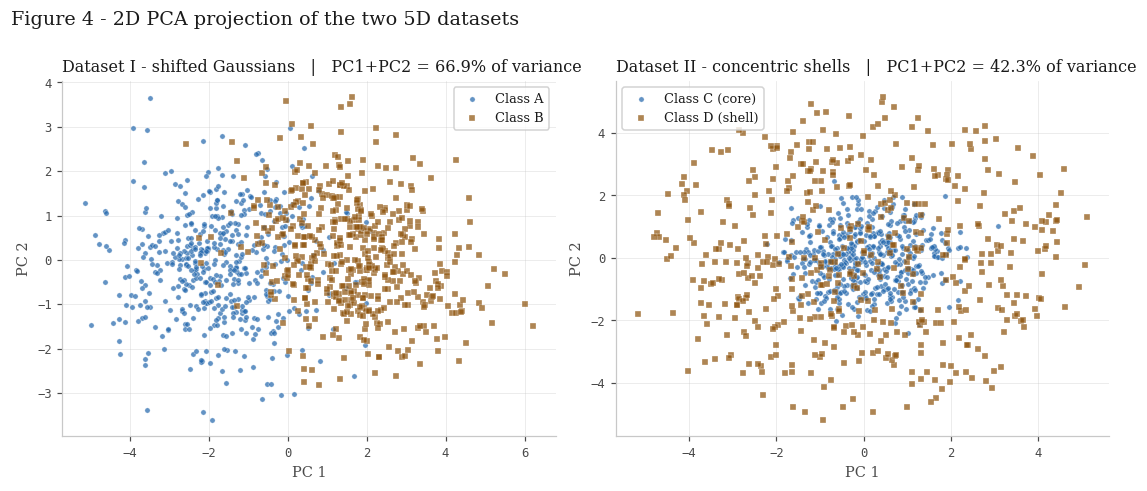

In [7]:
# ---- Figure 4 ---------------------------------------------------------------
def scatter2d(ax, Z, y, labels):
    for k in (0, 1):
        m = y == k
        ax.scatter(Z[m, 0], Z[m, 1], s=12, c=SERIES[k], marker=MARKERS[k],
                   alpha=0.7, linewidths=0.3, edgecolors=SURFACE, label=labels[k])
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")


proj = {"Dataset I - shifted Gaussians": (Z1, y1, p1.explained_variance_ratio_, lab1),
        "Dataset II - concentric shells": (Z2, y2, p2.explained_variance_ratio_, lab2)}

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.4))
for ax, (name, (Z, y, evr, labels)) in zip(axes, proj.items()):
    scatter2d(ax, Z, y, labels)
    ax.set_title(f"{name}   |   PC1+PC2 = {evr.sum():.1%} of variance",
                 fontfamily=SERIF, fontsize=10.5, loc="left")
    ax.legend(loc="best")
    mono_ticks(ax)
fig.suptitle("Figure 4 - 2D PCA projection of the two 5D datasets",
             fontfamily=SERIF, fontsize=12.5, x=0.008, ha="left", y=1.0)
fig.tight_layout()
plt.show()

In [8]:
measures = pd.DataFrame(
    [["Distance between class centres (5D)", f"{d1:.4f}", f"{d2:.4f}"],
     ["Explained variance PC1", f"{p1.explained_variance_ratio_[0]:.2%}",
      f"{p2.explained_variance_ratio_[0]:.2%}"],
     ["Explained variance PC2", f"{p1.explained_variance_ratio_[1]:.2%}",
      f"{p2.explained_variance_ratio_[1]:.2%}"],
     ["Explained variance PC1 + PC2", f"{p1.explained_variance_ratio_.sum():.2%}",
      f"{p2.explained_variance_ratio_.sum():.2%}"]],
    columns=["Measure", "Dataset I (Gaussians)", "Dataset II (shells)"])
measures

,Measure,Dataset I (Gaussians),Dataset II (shells)
0,Distance between class centres (5D),3.4056,0.2215
1,Explained variance PC1,51.43%,21.37%
2,Explained variance PC2,15.44%,20.90%
3,Explained variance PC1 + PC2,66.86%,42.27%


**Explained variance.** For Dataset I the first two components carry **66.86%** of the
variance (51.43% + 15.44%): the covariance structure is anisotropic — correlated features
plus a mean shift along all five axes — so a couple of directions summarise most of it.
For Dataset II they carry only **42.27%** (21.37% + 20.90%), barely above the $2/5 = 40\%$
that pure spherical symmetry would give: the shells have no privileged direction, so every
direction carries about the same variance and PCA has nothing to prioritise. Dropping three
of five dimensions therefore throws away three-fifths of the geometry.

**Which projection better preserves the information relevant for classification?**
**Dataset I.** In the left panel of Figure 4 the classes are displaced along PC1 and a
vertical line already separates most of them — the direction that matters for the label
(the difference of the means) is also a high-variance direction, so PCA keeps it. In the
right panel the label depends on $\lVert x \rVert$, a quantity that is *not* aligned with
any single direction; projecting shrinks the radius of every point by the component that
lived in the discarded dimensions, which is why some class D points land near the core in
the 2D view. The nested structure is still visible, but it stops being separable by a
straight line — and part of the radial information is genuinely destroyed by the projection.

**Distance between class centres (in 5D).**

* Dataset I: $\lVert c_A - c_B \rVert = \mathbf{3.4056}$, against the theoretical
  $\lVert \mu_B - \mu_A \rVert = 1.5\sqrt{5} = 3.3541$ — the small excess is sampling noise
  on 500 points per class.
* Dataset II: $\lVert c_C - c_D \rVert = \mathbf{0.2215}$, against a theoretical value of
  **exactly 0** — both shells are centred on the origin, and what remains is only the
  residual of averaging 500 random directions. For $n$ uniform directions on the sphere the
  mean vector satisfies $\mathbb{E}\lVert \bar{u} \rVert \approx 1/\sqrt{n} = 0.0447$, so the
  two empirical centres sit about $2 \times 0.0447 = 0.089$ and $5 \times 0.0447 = 0.224$
  from the origin and their difference has expected norm $\approx 0.24$. The observed
  $0.2215$ is exactly that — sampling noise, not signal.

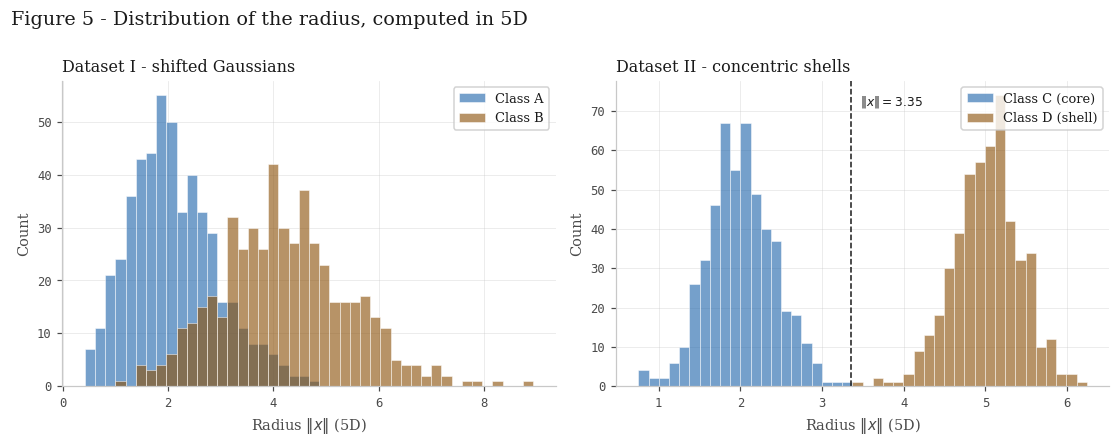

In [9]:
# ---- Figure 5: the radius, computed in the original 5D space ----------------
hists = {"Dataset I - shifted Gaussians": (X1, y1, lab1),
         "Dataset II - concentric shells": (X2, y2, lab2)}

fig, axes = plt.subplots(1, 2, figsize=(10.2, 4.0))
for ax, (name, (X, y, labels)) in zip(axes, hists.items()):
    r = radii(X)
    bins = np.linspace(r.min(), r.max(), 45)
    for k in (0, 1):
        ax.hist(r[y == k], bins=bins, color=SERIES[k], alpha=0.62,
                label=labels[k], edgecolor=SURFACE, linewidth=0.5)
    ax.set_xlabel("Radius $\\|x\\|$ (5D)")
    ax.set_ylabel("Count")
    ax.set_title(name, fontfamily=SERIF, fontsize=10.5, loc="left")
    ax.legend(loc="upper right")
    mono_ticks(ax)
axes[1].axvline(R_THRESHOLD, color=ACCENT, lw=1.0, ls="--")
axes[1].annotate(f"$\\|x\\| = {R_THRESHOLD}$", (R_THRESHOLD, axes[1].get_ylim()[1] * 0.92),
                 xytext=(6, 0), textcoords="offset points",
                 fontsize=8, family=MONO, color=ACCENT)
fig.suptitle("Figure 5 - Distribution of the radius, computed in 5D",
             fontfamily=SERIF, fontsize=12.5, x=0.008, ha="left", y=1.0)
fig.tight_layout()
plt.show()

In [10]:
r2 = radii(X2)
rad = pd.DataFrame(
    [["Class C (core)", f"{r2[y2 == 0].min():.4f}", f"{r2[y2 == 0].mean():.4f}",
      f"{r2[y2 == 0].max():.4f}"],
     ["Class D (shell)", f"{r2[y2 == 1].min():.4f}", f"{r2[y2 == 1].mean():.4f}",
      f"{r2[y2 == 1].max():.4f}"]],
    columns=["Class", "min ||x||", "mean ||x||", "max ||x||"])
print(f"gap between the two classes: {r2[y2 == 1].min() - r2[y2 == 0].max():.4f}")
rad

gap between the two classes: 0.1653


,Class,min ||x||,mean ||x||,max ||x||
0,Class C (core),0.7522,2.0039,3.2796
1,Class D (shell),3.4449,5.0175,6.2403


In Dataset II the two radius ranges are **disjoint**: the largest core radius is $3.2796$
and the smallest shell radius is $3.4449$, leaving an empty gap of $0.1653$ between the
classes — narrow, but a genuine gap, and no threshold inside it misclassifies a single one
of the 1000 points. In Dataset I, by contrast, the radius histograms overlap heavily
(class A spans $0.42\!-\!4.80$, class B $1.14\!-\!8.93$) — there the radius is the wrong
statistic, and the mean shift is the right one.

---
## D — Analysis

### Coincident centres + separated radii ⇒ no hyperplane can work

The combination is the signature of a **radially separable, linearly inseparable** problem.
A hyperplane is a rule of the form $w^\top x + b > 0$. Take any direction $w$: because
class D covers *all* directions uniformly at radius $\approx 5$, it has points with
$w^\top x \approx +5\lVert w \rVert$ and points with $w^\top x \approx -5\lVert w \rVert$;
class C does the same at radius $\approx 2$. So both classes always straddle the plane, and
every hyperplane misclassifies roughly half of one class. The near-zero centre distance says
the same thing from the other side: the best linear discriminant available to a
centres-based rule is the direction $c_D - c_C$, and that vector has almost no length
($0.2215$ against radii of 2 and 5) and a random orientation — it carries no information.
Meanwhile the radius histograms are cleanly separated, so the classes *are* perfectly
distinguishable — just not by a linear function of $x$.

### Why more data does not help

Linear inseparability here is a property of the **population**, not of the sample. The two
classes are supported on two concentric spherical shells; their convex hulls are nested
(the core is inside the convex hull of the shell), and a hyperplane can never separate a set
from a set that surrounds it. Collecting more points makes the sphere *denser*, so the
overlap of the projections onto any direction $w$ becomes more complete, not less: a
perceptron's best achievable accuracy stays at roughly the majority-class rate (~50% here),
and it converges to that plateau faster with more data. What is needed is not more data but
a **change of representation** — one non-linear feature, or one hidden layer able to compute
something like $\sum_i x_i^2$.

### Does a mixed 2D projection prove inseparability? No.

PCA is a **linear** transformation, and it optimises **variance**, not class separation.
A projection in which the classes look mixed therefore proves only one thing: that those two
particular high-variance directions do not separate them. It says nothing about the original
space. My own results make the point twice over:

* Dataset II's projection keeps only **42.27%** of the variance and shows a core inside a
  ring — visually structured, yet **no straight line** in that plane separates the classes;
* the very same data, measured in 5D with a single number per point ($\lVert x \rVert$),
  is **perfectly** separable, with an empty gap of $0.1653$ between the classes (Figure 5).

The information was never lost — the linear view simply could not express it as a half-plane.

### A function of the inputs that separates Dataset II

Take the squared radius and subtract a threshold in the empty gap, $t = 3.35$ (the
midpoint of $[3.2796,\ 3.4449]$):

$$
f(x) \;=\; \lVert x \rVert^2 - t^2 \;=\; \sum_{i=1}^{5} x_i^2 - 11.2225,
\qquad
\hat{y}(x) = \begin{cases}
\text{class D (shell)} & \text{if } f(x) > 0\\
\text{class C (core)}  & \text{if } f(x) \le 0
\end{cases}
$$

In [11]:
acc = radius_rule_accuracy(X2, y2, threshold=R_THRESHOLD)
print(f"accuracy of sign(||x||^2 - {R_THRESHOLD}^2) on all {len(y2)} points of Dataset II: {acc:.2%}")

# the rule is not delicate: the naive midpoint of the two nominal radii 2.0 and
# 5.0, chosen without looking at the data, already gets almost everything right
acc_naive = radius_rule_accuracy(X2, y2, threshold=3.5)
print(f"same rule with the naive threshold t = 3.5:                          {acc_naive:.2%}")

# for contrast: the same rule is useless on Dataset I, where the radius is the
# wrong statistic and the mean shift is the right one
print(f"same rule on Dataset I (wrong statistic, for contrast):              "
      f"{radius_rule_accuracy(X1, y1, threshold=R_THRESHOLD):.2%}")

accuracy of sign(||x||^2 - 3.35^2) on all 1000 points of Dataset II: 100.00%
same rule with the naive threshold t = 3.5:                          99.90%
same rule on Dataset I (wrong statistic, for contrast):              83.90%


Evaluated on all 1000 points, the rule gets **100.00%** of them right. The rule is not
delicate: the naive threshold $t = 3.5$, the midpoint of the two nominal radii $2.0$ and
$5.0$ chosen without looking at the data, already reaches **99.90%** (999 of 1000). Note
what it is: a *linear* classifier applied to the squared features $z_i = x_i^2$. That is
exactly the job of a hidden layer — learn a non-linear feature map, then separate linearly
in the new space.

In [12]:
# ---- numbers this notebook contributes to the report's Results summary -------
summary = {
    "distance between centres - Dataset I": f"{d1:.4f}",
    "distance between centres - Dataset II": f"{d2:.4f}",
    "explained variance PC1+PC2 - Dataset I": f"{p1.explained_variance_ratio_.sum():.2%}",
    "explained variance PC1+PC2 - Dataset II": f"{p2.explained_variance_ratio_.sum():.2%}",
}
for k, v in summary.items():
    print(f"{k:<42} {v}")

distance between centres - Dataset I       3.4056
distance between centres - Dataset II      0.2215
explained variance PC1+PC2 - Dataset I     66.86%
explained variance PC1+PC2 - Dataset II    42.27%
